In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import pandas as pd

In [61]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

In [62]:
import pandas as pd

# Lista de columnas de fechas en los datasets
columnas_fechas = ["created_at", "updated_at", "paid_at", "from_date", "to_date",
                    "cash_request_created_at", "cash_request_updated_at",
                    "reimbursement_date", "cash_request_received_date",
                    "money_back_date", "send_at", "moderated_at"]

# Función para convertir fechas eliminando la zona horaria
def convertir_fechas_sin_zona_horaria(df, columnas_fechas):
    for col in columnas_fechas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.tz_localize(None)
    return df

# Aplicar la conversión a ambos datasets
usuarios_activos = convertir_fechas_sin_zona_horaria(usuarios_activos, columnas_fechas)
usuarios_eliminados = convertir_fechas_sin_zona_horaria(usuarios_eliminados, columnas_fechas)



In [63]:
usuarios_activos["cohorte_primer_solicitud"] = usuarios_activos.groupby("user_id")["created_at"].transform("min").dt.to_period("M")
usuarios_eliminados["cohorte_primer_solicitud"] = usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("min").dt.to_period("M")

In [64]:
usuarios_eliminados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 40 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   id                                       906 non-null    int64         
 1   cash_request_id                          906 non-null    int64         
 2   type                                     906 non-null    object        
 3   status                                   906 non-null    object        
 4   category                                 166 non-null    object        
 5   total_amount                             906 non-null    float64       
 6   reason                                   906 non-null    object        
 7   created_at                               906 non-null    datetime64[ns]
 8   updated_at                               906 non-null    datetime64[ns]
 9   paid_at                                  50

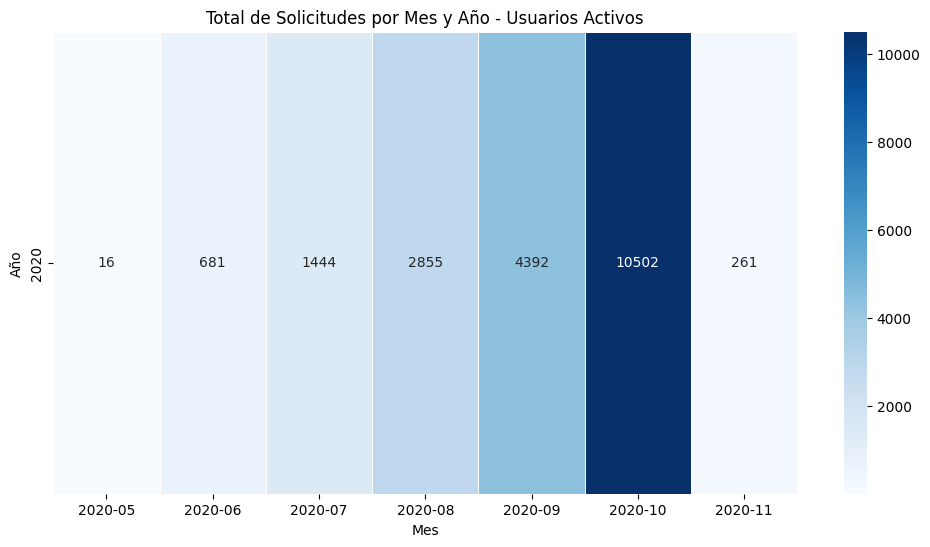

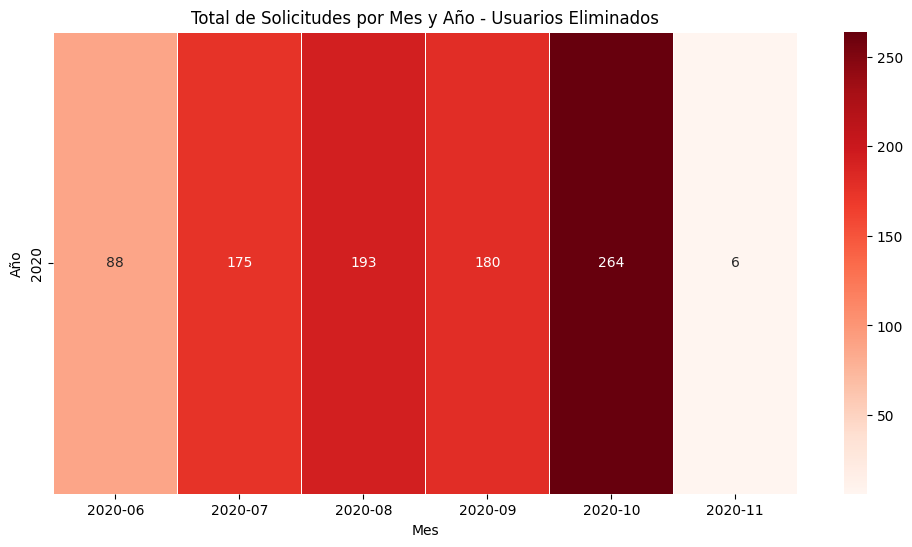

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes por mes y año en usuarios activos
solicitudes_por_mes_activos = usuarios_activos.groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y año en usuarios eliminados
solicitudes_por_mes_eliminados = usuarios_eliminados.groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


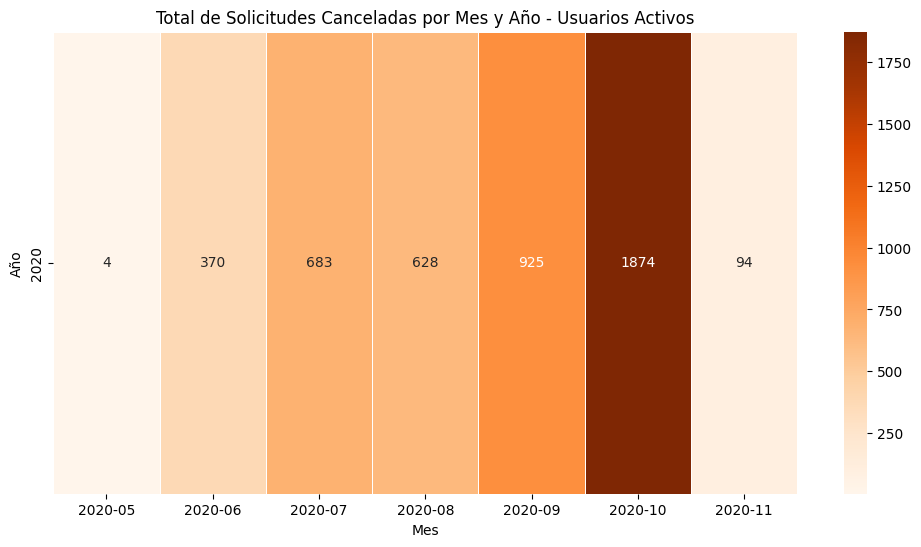

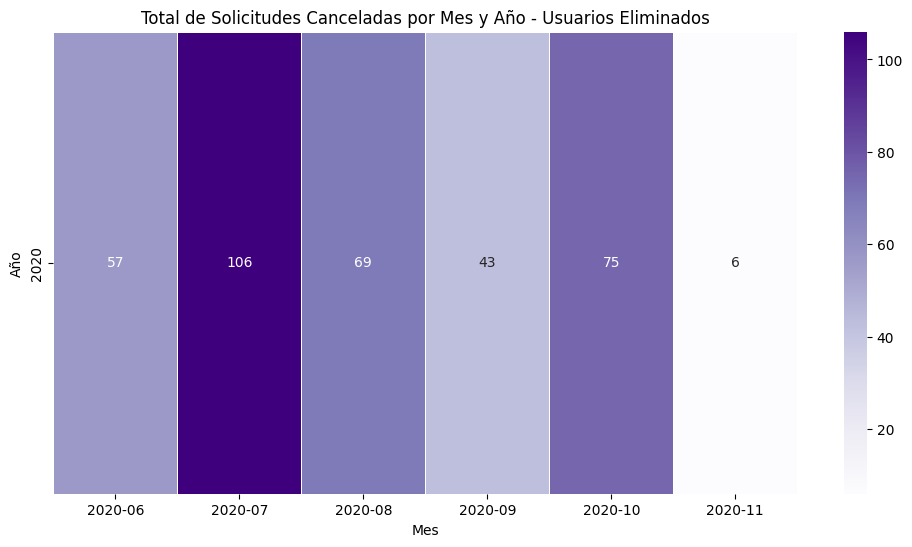

In [50]:
# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios activos
canceladas_por_mes_activos = usuarios_activos[usuarios_activos["status"] == "cancelled"].groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios eliminados
canceladas_por_mes_eliminados = usuarios_eliminados[usuarios_eliminados["status"] == "cancelled"].groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para solicitudes canceladas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para solicitudes canceladas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


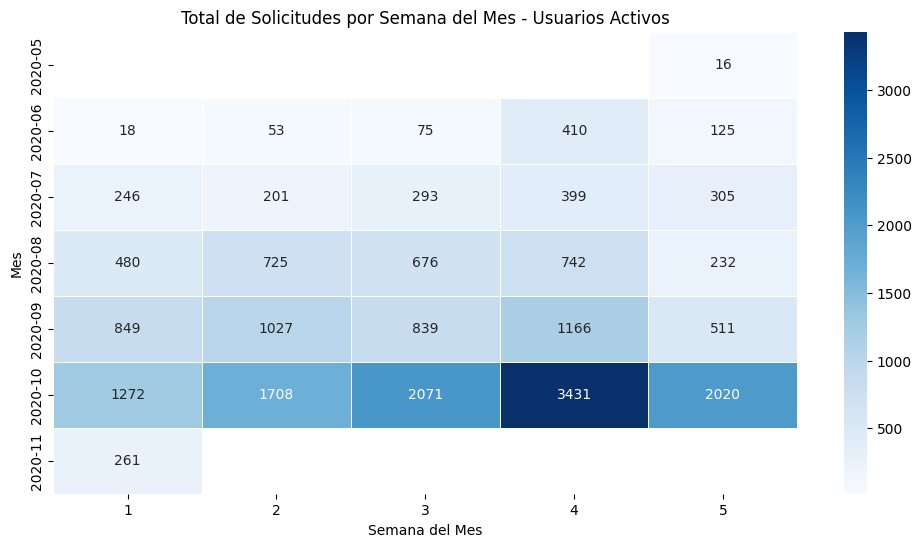

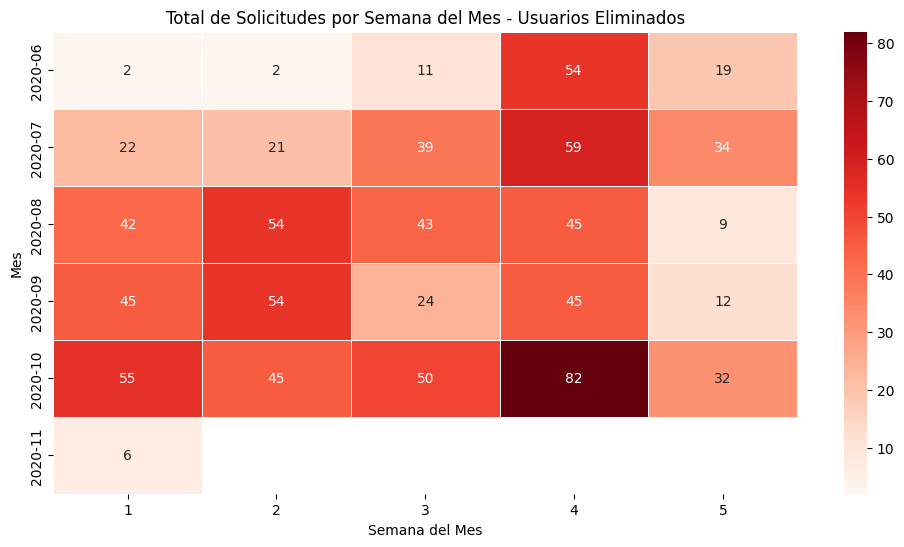

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una nueva columna con la semana dentro del mes
usuarios_activos["semana_mes_solicitud"] = usuarios_activos["created_at"].dt.day // 7 + 1
usuarios_eliminados["semana_mes_solicitud"] = usuarios_eliminados["created_at"].dt.day // 7 + 1

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios activos
solicitudes_por_semana_mes_activos = usuarios_activos.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios eliminados
solicitudes_por_semana_mes_eliminados = usuarios_eliminados.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Crear la matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


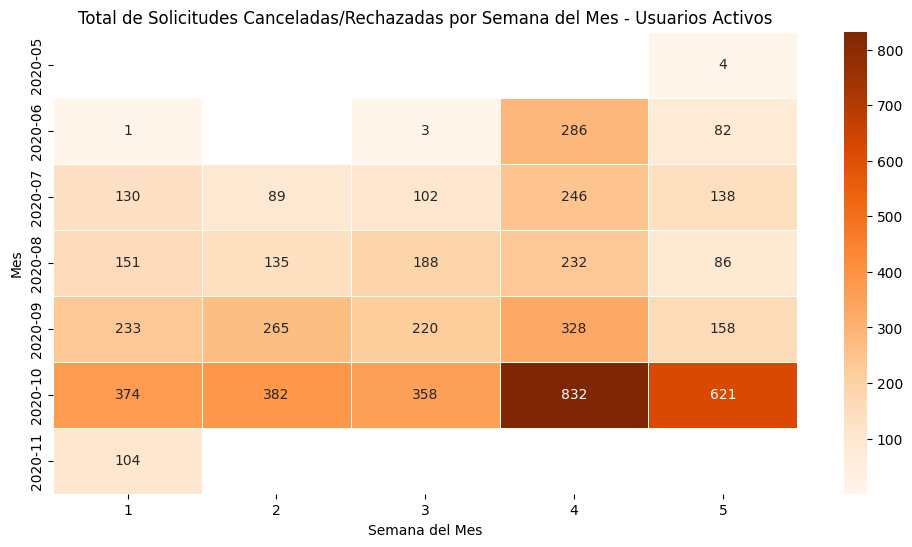

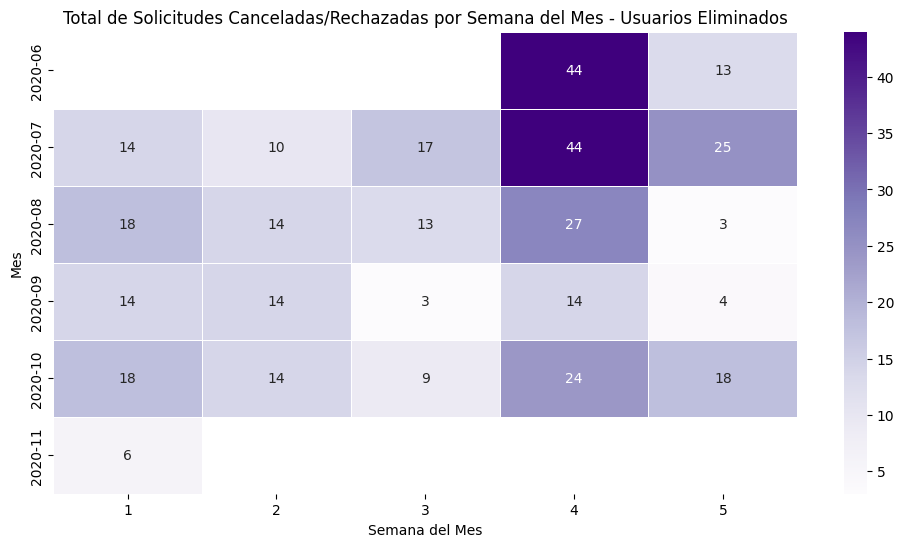

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios activos
canceladas_rechazadas_por_semana_mes_activos = usuarios_activos[
    usuarios_activos["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios eliminados
canceladas_rechazadas_por_semana_mes_eliminados = usuarios_eliminados[
    usuarios_eliminados["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["deleted_account_id"].count().unstack()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


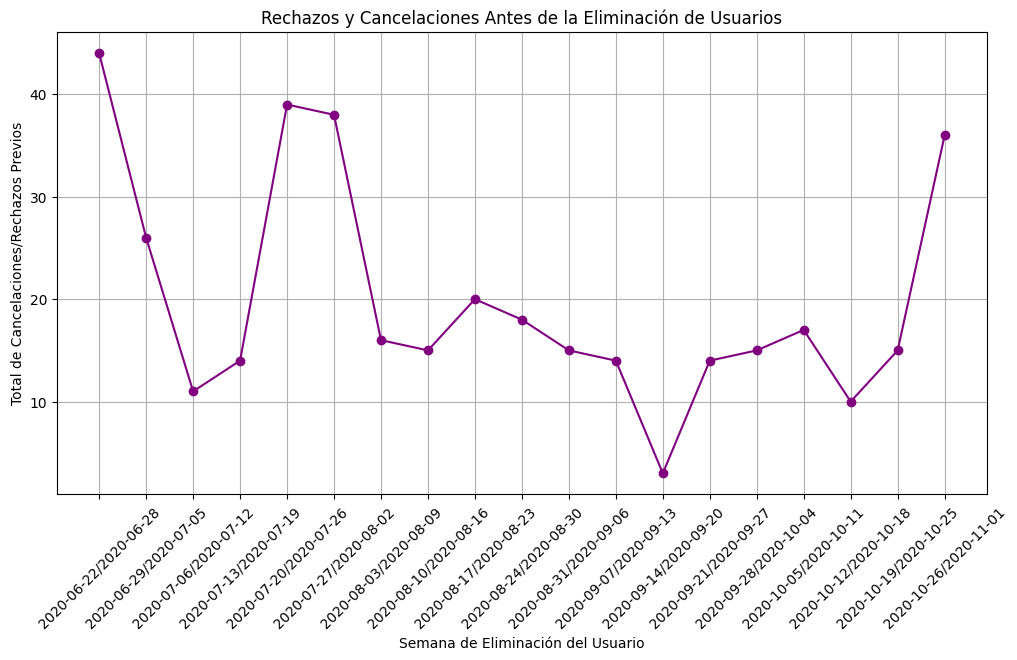

In [26]:
import matplotlib.pyplot as plt

# Crear una nueva columna con la semana en la que el usuario fue eliminado (para usuarios eliminados)
usuarios_eliminados["semana_eliminacion"] = usuarios_eliminados["created_at"].dt.to_period("W")

# Contar cuántas solicitudes canceladas/rechazadas ocurrieron en las semanas previas a la eliminación
rechazos_previos_eliminacion = usuarios_eliminados[usuarios_eliminados["status"].isin(["cancelled", "rejected"])].groupby(
    ["deleted_account_id", "semana_eliminacion"]
)["deleted_account_id"].count().reset_index(name="rechazos_previos")

# Agrupar por semana de eliminación para ver la tendencia
rechazos_antes_de_eliminar = rechazos_previos_eliminacion.groupby("semana_eliminacion")["rechazos_previos"].sum()

# Graficar la evolución de rechazos antes de la eliminación de usuarios
plt.figure(figsize=(12, 6))
plt.plot(rechazos_antes_de_eliminar.index.astype(str), rechazos_antes_de_eliminar.values, marker="o", linestyle="-", color="purple")
plt.xticks(rotation=45)
plt.xlabel("Semana de Eliminación del Usuario")
plt.ylabel("Total de Cancelaciones/Rechazos Previos")
plt.title("Rechazos y Cancelaciones Antes de la Eliminación de Usuarios")
plt.grid()
plt.show()


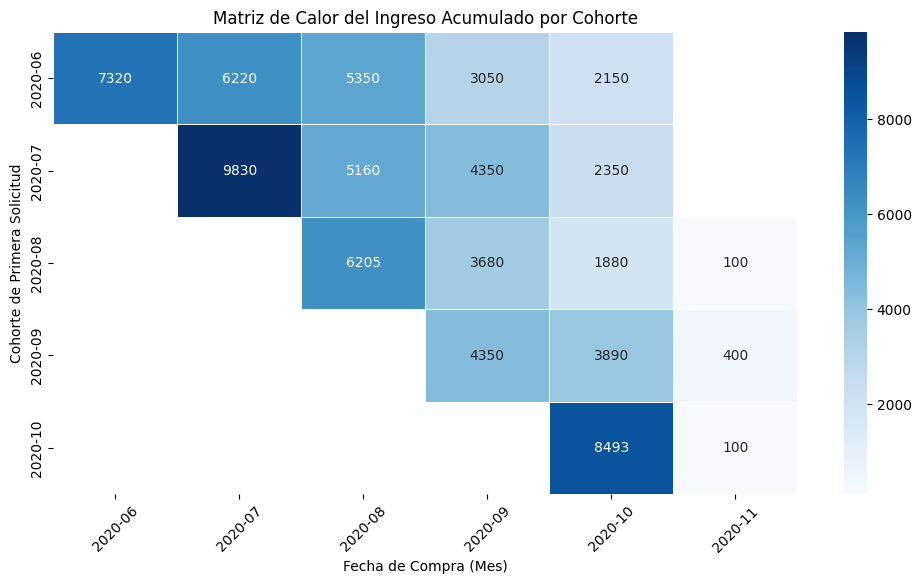

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear columna de mes de compra
usuarios_eliminados["Fecha_Compra"] = usuarios_eliminados["created_at"].dt.to_period("M")

# Calcular los ingresos acumulados por cohorte y fecha de compra
usuarios_eliminados["Ingresos_Acumulados"] = usuarios_eliminados.groupby(
    ["cohorte_primer_solicitud", "Fecha_Compra"]
)["amount"].transform("sum")

# Crear tabla pivote con cohortes en filas y meses de compra en columnas
ingresos_heatmap = usuarios_eliminados.pivot_table(
    index="cohorte_primer_solicitud",
    columns="Fecha_Compra",
    values="Ingresos_Acumulados",
    aggfunc="mean"
)

# Visualización con heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(ingresos_heatmap, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Matriz de Calor del Ingreso Acumulado por Cohorte")
plt.xlabel("Fecha de Compra (Mes)")
plt.ylabel("Cohorte de Primera Solicitud")
plt.xticks(rotation=45)
plt.show()
